# Product Demand Clustering for Hidden Seasonality Detection

## Overview

This notebook develops a demand typology for the full product catalogue of 7,775 products based on temporal sales patterns extracted from hourly data covering January–December 2025.

The initial approach applied standard clustering algorithms — K-Means and HDBSCAN — to a set of product-level statistical features computed over all hourly observations. This produced degenerate results: HDBSCAN classified over 96% of products as noise, and K-Means converged to clusters separable only by sales volume rather than temporal pattern. The root cause is structural: approximately 97% of all hourly observations carry zero sales. Any feature computed over all hours is dominated by the zero-rate signal, which suppresses all seasonality information.

The solution was to restrict feature computation exclusively to hours where sales > 0. This reframes the question from "does this product sell?" to "when this product sells, what is the temporal pattern?" Features are expressed as fractional shares across days of week, months, and hours of day, making all products directly comparable regardless of volume. Following this transformation, clustering produced a coherent two-cluster solution separating winter-heavy from summer-heavy demand profiles.

However, a single cluster label was found insufficient for the research objectives, since seasonality axes are orthogonal: a product can simultaneously be summer-seasonal, weekend-peaked, and evening-concentrated. The final methodology therefore assigns each product four independent typology labels — one per seasonality dimension — rather than a single master cluster.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA_PATH    = r'C:\Users\User\Desktop\диплом\data_v1.csv'
RANDOM_STATE = 42

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

### Data Loading and Cold-Start Filtering

Loads the full dataset and removes products whose first positive sale occurred on or after 1 August 2025, consistent with the filtering applied in the main modelling notebook.

In [2]:
df = pd.read_csv(DATA_PATH)
df['date']    = pd.to_datetime(df['date'])
df['product'] = df['product'].astype(str)

first_pos = df[df['sales'] > 0].groupby('product')['date'].min()
cold      = first_pos[first_pos >= '2025-08-01'].index
df        = df[~df['product'].isin(cold)].copy()

df['hour']      = df['date'].dt.hour
df['dayofweek'] = df['date'].dt.dayofweek   # 0=Mon, 6=Sun
df['month']     = df['date'].dt.month
df['week']      = df['date'].dt.isocalendar().week.astype(int)
df['is_weekend']= (df['dayofweek'] >= 5).astype(int)

print(f"Dataset: {df.shape[0]:,} rows | {df['product'].nunique():,} products")
print(f"Period:  {df['date'].min().date()} → {df['date'].max().date()}")

Dataset: 59,441,640 rows | 7,775 products
Period:  2025-01-15 → 2025-12-27


### Feature Engineering on Active Hours Only

The core methodological challenge in this dataset is that approximately 97% of all hourly observations have zero sales. Computing seasonality features over all hours conflates genuine demand absence with structural zeros, causing zero-rate to dominate the feature space and suppress all seasonality signals.

The solution is to compute features exclusively on hours where sales > 0 — the "active" observations. This transforms the question from "does this product sell?" to "when this product sells, what is the temporal pattern?" Features are then expressed as shares (fractions summing to 1) across days of week, months, and hours of day, making products directly comparable regardless of their overall volume.

Four feature blocks are constructed:
- **Volume on active hours** — mean sales, CV, total active hour count, 90th percentile
- **Day-of-week share** — fraction of active sales hours falling on each weekday (7 values)
- **Month share** — fraction of active sales hours falling in each month (up to 8 values)
- **Hour-of-day share** — fraction of active sales hours falling in each hour (24 values)

In [3]:
df['hour']      = df['date'].dt.hour
df['dayofweek'] = df['date'].dt.dayofweek
df['month']     = df['date'].dt.month

df_active = df[df['sales'] > 0].copy()
g_active  = df_active.groupby('product')

print(f"Active observations: {len(df_active):,} "
      f"({len(df_active)/len(df):.1%} of total)")
print(f"Products with at least one sale: {df_active['product'].nunique():,}")

vol_active = g_active['sales'].agg(
    mean_sales_active = 'mean',
    cv_active         = lambda x: x.std() / (x.mean() + 1e-6),
    n_active_hours    = 'count',
    p90_active        = lambda x: np.percentile(x, 90),
).reset_index()

vol_active['mean_sales_active'] = np.log1p(vol_active['mean_sales_active'])
vol_active['n_active_hours']    = np.log1p(vol_active['n_active_hours'])
vol_active['p90_active']        = np.log1p(vol_active['p90_active'])

dow_active = (df_active.groupby(['product', 'dayofweek'])['sales']
              .count()
              .unstack(fill_value=0))
dow_active = dow_active.div(dow_active.sum(axis=1), axis=0)
dow_active.columns = [f'dow_share_{c}' for c in dow_active.columns]
dow_active = dow_active.reset_index()

month_active = (df_active.groupby(['product', 'month'])['sales']
                .count()
                .unstack(fill_value=0))
month_active = month_active.div(month_active.sum(axis=1), axis=0)
month_active.columns = [f'month_share_{c}' for c in month_active.columns]
month_active = month_active.reset_index()

hour_active = (df_active.groupby(['product', 'hour'])['sales']
               .count()
               .unstack(fill_value=0))
hour_active = hour_active.div(hour_active.sum(axis=1), axis=0)
hour_active.columns = [f'hour_share_{c}' for c in hour_active.columns]
hour_active = hour_active.reset_index()

features_active = vol_active.copy()
for frame in [dow_active, month_active, hour_active]:
    features_active = features_active.merge(frame, on='product', how='left')

features_active = features_active.fillna(0)

vol_cols   = ['mean_sales_active', 'cv_active', 'n_active_hours', 'p90_active']
dow_cols   = [c for c in features_active.columns if c.startswith('dow_share_')]
month_cols = [c for c in features_active.columns if c.startswith('month_share_')]
hour_cols  = [c for c in features_active.columns if c.startswith('hour_share_')]
feature_cols = vol_cols + dow_cols + month_cols + hour_cols

print(f"\nFeature matrix: {len(features_active):,} products × {len(feature_cols)} features")
print(f"  volume: {len(vol_cols)} | dow: {len(dow_cols)} | "
      f"month: {len(month_cols)} | hour: {len(hour_cols)}")

Active observations: 2,012,146 (3.4% of total)
Products with at least one sale: 7,775

Feature matrix: 7,775 products × 47 features
  volume: 4 | dow: 7 | month: 12 | hour: 24


### Multidimensional Demand Typology

1. **Monthly seasonality** — dominant season (winter, spring, summer, autumn) if share ≥ 45%
2. **Holiday-driven** — February, March, May, December share > 55% with low summer months
3. **Weekly seasonality** — fri_sat_peak, weekend_peak, weekday_focused, uniform_weekly
4. **Hourly seasonality** — dominant time of day (morning, afternoon, evening, night) if share ≥ 40%


In [4]:
fa = features_active.copy()

month_cols_num = [c for c in fa.columns if c.startswith('month_share_')]

fa['share_winter'] = fa[['month_share_1','month_share_2','month_share_12']].sum(axis=1)
fa['share_spring'] = fa[['month_share_3','month_share_4','month_share_5']].sum(axis=1)
fa['share_summer'] = fa[['month_share_6','month_share_7','month_share_8']].sum(axis=1)
fa['share_autumn'] = fa[['month_share_9','month_share_10','month_share_11']].sum(axis=1)

def seasonal_type(row, threshold=0.45):
    s = {'winter': row['share_winter'],
         'spring': row['share_spring'],
         'summer': row['share_summer'],
         'autumn': row['share_autumn']}
    best = max(s, key=s.get)
    if s[best] >= threshold:
        return best
    return 'no_seasonality'

fa['monthly_type'] = fa.apply(seasonal_type, axis=1)
print("Monthly seasonality types:")
print(fa['monthly_type'].value_counts())

fa['share_holiday'] = fa[['month_share_2','month_share_3',
                            'month_share_5','month_share_12']].sum(axis=1)

fa['is_holiday_driven'] = (
    (fa['share_holiday'] > 0.55) &
    (fa[['month_share_6','month_share_7','month_share_8',
          'month_share_9','month_share_10']].max(axis=1) < 0.12)
).astype(int)
print(f"\nHoliday-driven products: {fa['is_holiday_driven'].sum()}")

dow_cols_num = [c for c in fa.columns if c.startswith('dow_share_')]

fa['share_weekdays']  = fa[['dow_share_0','dow_share_1','dow_share_2',
                              'dow_share_3','dow_share_4']].sum(axis=1)
fa['share_weekend']   = fa[['dow_share_5','dow_share_6']].sum(axis=1)
fa['share_fri_sat']   = fa[['dow_share_4','dow_share_5']].sum(axis=1)

def weekly_type(row, threshold=0.35):
    if row['share_fri_sat'] >= threshold:
        return 'fri_sat_peak'
    elif row['share_weekend'] >= threshold:
        return 'weekend_peak'
    elif row['share_weekdays'] >= 0.75:
        return 'weekday_focused'
    else:
        return 'uniform_weekly'

fa['weekly_type'] = fa.apply(weekly_type, axis=1)
print("\nWeekly seasonality types:")
print(fa['weekly_type'].value_counts())

hour_cols_num = [c for c in fa.columns if c.startswith('hour_share_')]

fa['share_morning']   = fa[[f'hour_share_{h}' for h in range(6, 12)
                              if f'hour_share_{h}' in fa.columns]].sum(axis=1)
fa['share_afternoon'] = fa[[f'hour_share_{h}' for h in range(12, 17)
                              if f'hour_share_{h}' in fa.columns]].sum(axis=1)
fa['share_evening']   = fa[[f'hour_share_{h}' for h in range(17, 23)
                              if f'hour_share_{h}' in fa.columns]].sum(axis=1)
fa['share_night']     = fa[[f'hour_share_{h}' for h in list(range(0, 6)) + [23]
                              if f'hour_share_{h}' in fa.columns]].sum(axis=1)

def hourly_type(row, threshold=0.40):
    s = {'morning':   row['share_morning'],
         'afternoon': row['share_afternoon'],
         'evening':   row['share_evening'],
         'night':     row['share_night']}
    best = max(s, key=s.get)
    if s[best] >= threshold:
        return best
    return 'uniform_hourly'

fa['hourly_type'] = fa.apply(hourly_type, axis=1)
print("\nHourly seasonality types:")
print(fa['hourly_type'].value_counts())

type_cols = ['product', 'n_active_hours', 'cv_active',
             'monthly_type', 'is_holiday_driven',
             'weekly_type', 'hourly_type',
             'share_winter','share_spring','share_summer','share_autumn',
             'share_fri_sat','share_weekend',
             'share_morning','share_afternoon','share_evening']

print("\nSample of typology table")
print(fa[type_cols].sample(10, random_state=42).to_string(index=False))

pivot = pd.crosstab(fa['monthly_type'], fa['weekly_type'],
                    margins=True, margins_name='Total')
print("\nMonthly × Weekly cross-tabulation:")
print(pivot.to_string())

Monthly seasonality types:
monthly_type
no_seasonality    4023
summer            1493
spring            1027
winter             804
autumn             428
Name: count, dtype: int64

Holiday-driven products: 775

Weekly seasonality types:
weekly_type
uniform_weekly     4558
weekday_focused    2090
fri_sat_peak        646
weekend_peak        481
Name: count, dtype: int64

Hourly seasonality types:
hourly_type
evening           2970
uniform_hourly    2589
afternoon         1950
morning            255
night               11
Name: count, dtype: int64

Sample of typology table
        product  n_active_hours  cv_active   monthly_type  is_holiday_driven     weekly_type    hourly_type  share_winter  share_spring  share_summer  share_autumn  share_fri_sat  share_weekend  share_morning  share_afternoon  share_evening
178462000265731        5.817111   0.292968 no_seasonality                  0  uniform_weekly uniform_hourly      0.200000      0.253731      0.388060      0.158209       0.247761   

### Seasonality Typology Visualizations

Two-panel figure:

1. **Distribution of typology labels** — bar charts showing product counts for monthly, weekly, hourly seasonality types and holiday-driven classification.

2. **Normalized monthly demand profiles** — average sales by month for each seasonality type, normalized to peak month. Dashed line shows uniform baseline.

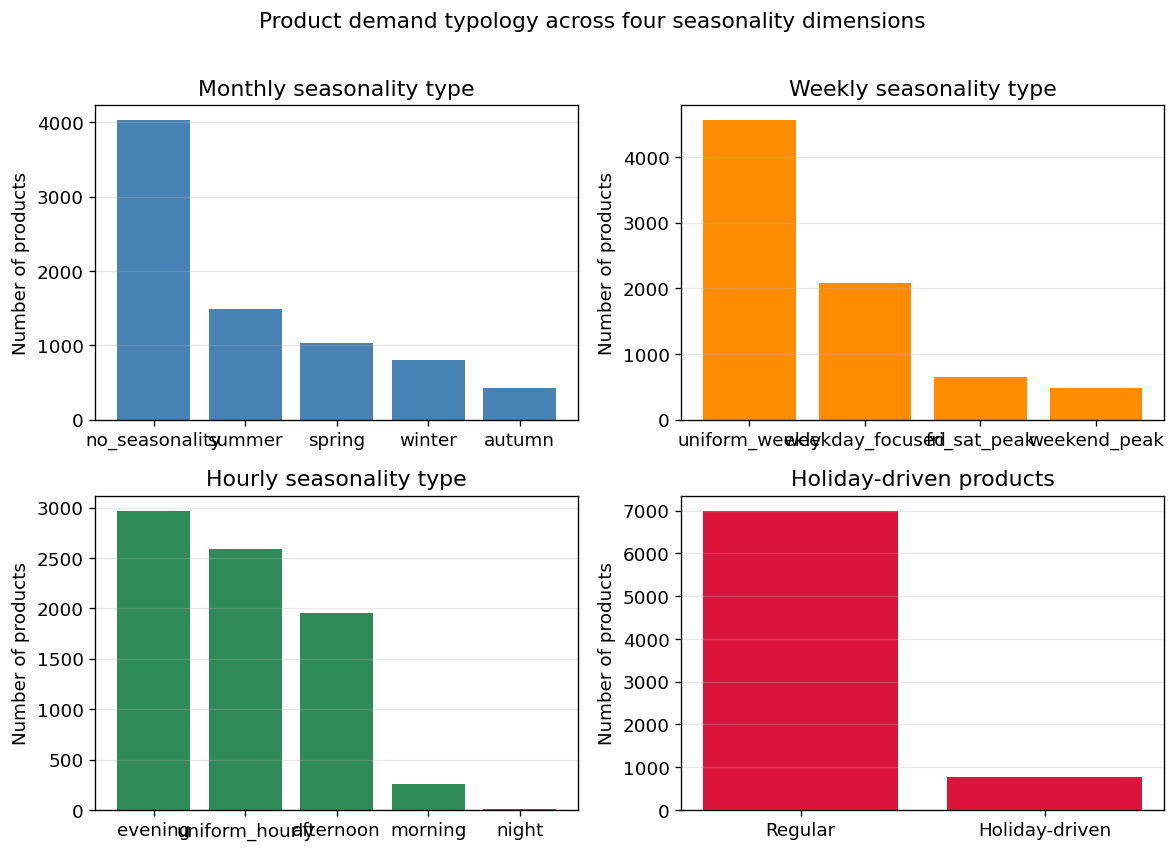

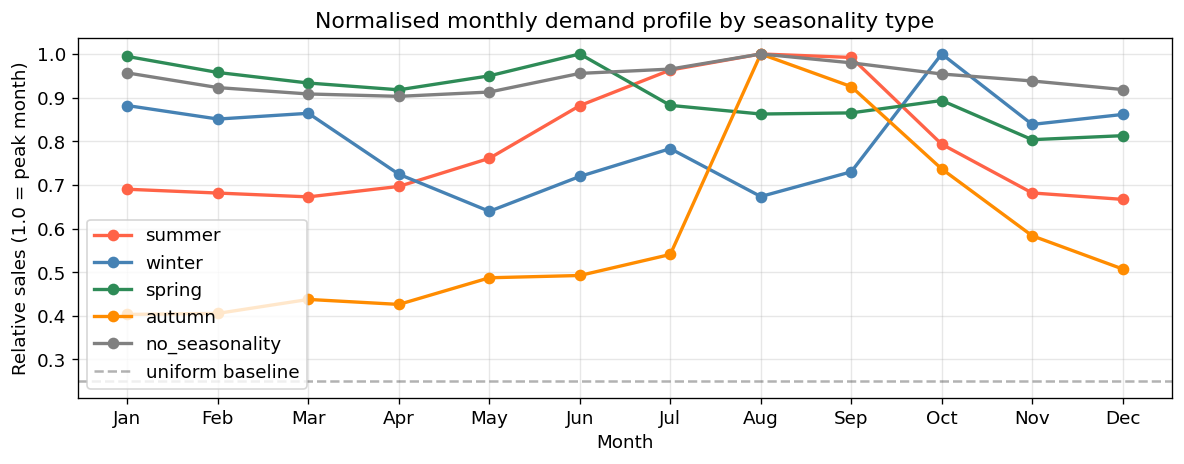

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

counts_m = fa['monthly_type'].value_counts()
axes[0,0].bar(counts_m.index, counts_m.values, color='steelblue')
axes[0,0].set_title('Monthly seasonality type')
axes[0,0].set_ylabel('Number of products')
axes[0,0].grid(axis='y', alpha=0.3)
axes[0,0].tick_params(axis='x', rotation=45)

counts_w = fa['weekly_type'].value_counts()
axes[0,1].bar(counts_w.index, counts_w.values, color='darkorange')
axes[0,1].set_title('Weekly seasonality type')
axes[0,1].set_ylabel('Number of products')
axes[0,1].grid(axis='y', alpha=0.3)
axes[0,1].tick_params(axis='x', rotation=45)

counts_h = fa['hourly_type'].value_counts()
axes[1,0].bar(counts_h.index, counts_h.values, color='seagreen')
axes[1,0].set_title('Hourly seasonality type')
axes[1,0].set_ylabel('Number of products')
axes[1,0].grid(axis='y', alpha=0.3)
axes[1,0].tick_params(axis='x', rotation=45)

holiday_counts = fa['is_holiday_driven'].map({0: 'Regular', 1: 'Holiday-driven'}).value_counts()
axes[1,1].bar(holiday_counts.index, holiday_counts.values, color='crimson')
axes[1,1].set_title('Holiday-driven products')
axes[1,1].set_ylabel('Number of products')
axes[1,1].grid(axis='y', alpha=0.3)

plt.suptitle('Product demand typology across four seasonality dimensions', 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

monthly_profiles = df.merge(fa[['product','monthly_type']], on='product', how='left')
monthly_profiles = monthly_profiles[monthly_profiles['sales'] > 0]
mp = monthly_profiles.groupby(['monthly_type','month'])['sales'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))

for mtype, color in zip(['summer','winter','spring','autumn','no_seasonality'],
                         ['tomato','steelblue','seagreen','darkorange','grey']):
    d = mp[mp['monthly_type'] == mtype].copy()
    d['sales_norm'] = d['sales'] / d['sales'].max()
    ax.plot(d['month'], d['sales_norm'], marker='o', label=mtype, 
            color=color, linewidth=2)

ax.set_title('Normalised monthly demand profile by seasonality type')
ax.set_xlabel('Month')
ax.set_ylabel('Relative sales (1.0 = peak month)')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.axhline(y=1/12*3, color='black', linestyle='--', alpha=0.3, label='uniform baseline')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusions

The multi-dimensional typology assigns each of the 7,775 products four independent demand labels.

**Monthly seasonality** classifies 48% of the catalogue into seasonal archetypes. Summer products (1,493 SKUs) peak in July–August; autumn products (428 SKUs) show the sharpest signal with sales collapsing to 40% of peak during winter; winter products (804 SKUs) peak in October–November; spring products (1,027 SKUs) show the weakest differentiation. The remaining 4,023 products have no dominant monthly pattern.

**Holiday concentration** flags 775 products (~10% of catalogue) whose sales are disproportionately concentrated in February, March, May, and December. For these products, low sales outside holiday windows are structurally normal and should not trigger anomaly alerts.

**Weekly rhythm** identifies 646 products with a Friday–Saturday peak and 481 with broader weekend concentration. The majority are either uniform (4,558) or weekday-focused (2,090).

**Intraday pattern** shows evening dominance (2,970 products) as the largest group. Only 255 products are morning-peaked, indicating a small category of early-day SKUs.

These typology labels have direct implications for the anomaly detection pipeline: a summer product with near-zero sales in January or a Friday-peaked product with low midweek sales should not be flagged as anomalies. Incorporating demand type as a stratification layer in threshold calibration is a natural direction for future work, enabling per-archetype sensitivity tuning without model retraining.